In [ ]:
!apt-get update
!apt-get install -y tshark
!pip install scikit-learn pandas numpy seaborn matplotlib pyshark

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 6,555 B in 2s (3,327 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tshark is already the newest version (3.6.2-2).
0 

## Feature Selection and Extraction

In [ ]:
import pyshark
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from tqdm import tqdm
import warnings
import asyncio
import nest_asyncio

warnings.filterwarnings("ignore")

# Set the event loop policy to allow nested event loops
asyncio.set_event_loop_policy(asyncio.DefaultEventLoopPolicy())
nest_asyncio.apply()

PCAP_FILES = [
    "capture_loss0.pcap",
    "capture_loss10.pcap",
    "capture_loss15.pcap",
    "capture_loss5.pcap",
    "capture_loss20.pcap"
]

OUTPUT_CSV = "features_selected.csv"
TOP_K = 10
PCA_COMPONENTS = 5


def parse_pcap(pcap_file):
    print(f"\n[*] Parsing {pcap_file} ...")
    cap = pyshark.FileCapture(pcap_file, display_filter="tcp")

    def to_int(val):
        try:
            return int(val)
        except:
            return 1 if str(val).strip().lower() == "true" else 0

    records = []

    for pkt in tqdm(cap, desc=f"Packets ({pcap_file})", unit="pkt"):
        try:
            tcp = pkt.tcp
            ip = pkt.ip

            record = {
                "ip_ttl": int(ip.ttl),
                "ip_len": int(ip.len),
                "ip_proto": int(ip.proto),

                "tcp_srcport": int(tcp.srcport),
                "tcp_dstport": int(tcp.dstport),
                "tcp_seq": int(tcp.seq),
                "tcp_ack": int(tcp.ack),
                "tcp_len": int(tcp.len),
                "tcp_window_size": int(tcp.window_size_value),
                "tcp_hdr_len": int(tcp.hdr_len),

                "flag_syn": to_int(tcp.flags_syn),
                "flag_ack": to_int(tcp.flags_ack),
                "flag_fin": to_int(tcp.flags_fin),
                "flag_rst": to_int(tcp.flags_reset),
                "flag_push": to_int(tcp.flags_push),
                "flag_urg": to_int(tcp.flags_urg),

                "frame_time_delta": float(pkt.frame_info.time_delta),
                "frame_time_epoch": float(pkt.frame_info.time_epoch),

                # Label
                "packet_loss": 1 if hasattr(tcp, "analysis_retransmission") else 0,
            }

            records.append(record)

        except AttributeError:
            continue

    cap.close()

    df = pd.DataFrame(records)

    if df.empty:
        print(f"[!] No TCP packets found in {pcap_file}")
        return df

    df["frame_time_epoch"] = df["frame_time_epoch"] - df["frame_time_epoch"].min()

    print(f"[+] {pcap_file}: {len(df)} packets | Loss: {df['packet_loss'].sum()}")

    return df


def parse_multiple_pcaps(pcap_files):
    all_dfs = []

    for i, file in enumerate(pcap_files):
        df = parse_pcap(file)

        if not df.empty:
            df["file_id"] = i
            df["source_file"] = file
            all_dfs.append(df)

    if not all_dfs:
        raise ValueError("❌ No valid data extracted from PCAP files.")

    combined_df = pd.concat(all_dfs, ignore_index=True)

    print("\n[+] COMBINED DATASET SUMMARY")
    print(f"Total packets : {len(combined_df)}")
    print(f"Columns       : {len(combined_df.columns)}")
    print(f"Loss distribution:\n{combined_df['packet_loss'].value_counts()}")

    return combined_df


def engineer_features(df):
    df = df.sort_values(["file_id", "frame_time_epoch"]).reset_index(drop=True)

    steps = [
        ("Inter-arrival time", lambda d: d.groupby("file_id")["frame_time_epoch"].diff().fillna(0)),
        ("Sequence delta", lambda d: d.groupby("file_id")["tcp_seq"].diff().fillna(0)),
        ("ACK delta", lambda d: d.groupby("file_id")["tcp_ack"].diff().fillna(0)),
        ("Rolling mean len", lambda d: d.groupby("file_id")["tcp_len"].rolling(5, min_periods=1).mean().reset_index(level=0, drop=True)),
        ("Rolling std len", lambda d: d.groupby("file_id")["tcp_len"].rolling(5, min_periods=1).std().fillna(0).reset_index(level=0, drop=True)),
        ("Rolling loss rate", lambda d: d.groupby("file_id")["packet_loss"].rolling(10, min_periods=1).mean().reset_index(level=0, drop=True)),
    ]

    col_names = ["iat", "seq_delta", "ack_delta",
                 "rolling_mean_len", "rolling_std_len", "rolling_loss_rate"]

    for (desc, fn), col in tqdm(zip(steps, col_names), total=len(steps),
                               desc="Engineering features", unit="feature"):
        df[col] = fn(df)

    return df


def select_features(df, top_k=TOP_K, n_pca=PCA_COMPONENTS):
    label_col = "packet_loss"
    drop_cols = [label_col, "frame_time_epoch", "source_file", "file_id"]

    X = df.drop(columns=drop_cols, errors="ignore").fillna(0)
    y = df[label_col]

    feature_names = X.columns.tolist()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # SelectKBest
    selector = SelectKBest(score_func=f_classif, k=min(top_k, len(feature_names)))
    selector.fit(X_scaled, y)
    kbest_scores = pd.Series(selector.scores_, index=feature_names).sort_values(ascending=False)
    kbest_features = set(kbest_scores.head(top_k).index.tolist())

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_scaled, y)
    rf_scores = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
    rf_features = set(rf_scores.head(top_k).index.tolist())

    # PCA
    pca = PCA(n_components=min(n_pca, X_scaled.shape[1]))
    pca.fit(X_scaled)
    explained = pca.explained_variance_ratio_

    loadings = pd.DataFrame(
        pca.components_.T,
        index=feature_names,
        columns=[f"PC{i+1}" for i in range(pca.n_components_)]
    )
    pca_features = set(loadings.abs().max(axis=1).sort_values(ascending=False).head(top_k).index.tolist())

    # INTERSECTION of all three
    intersection = kbest_features & rf_features & pca_features
    ordered_intersection = [f for f in feature_names if f in intersection]

    print("\n[+] Feature Selection Results")
    print(f"  KBest ({len(kbest_features)}) : {sorted(kbest_features)}")
    print(f"  RF    ({len(rf_features)}) : {sorted(rf_features)}")
    print(f"  PCA   ({len(pca_features)}) : {sorted(pca_features)}")
    print(f"\n✅ Intersection ({len(intersection)}) : {sorted(intersection)}")
    print("Explained variance:", np.round(explained, 3), "Total:", explained.sum())

    if len(intersection) == 0:
        raise ValueError("❌ Intersection is empty! Try increasing TOP_K.")

    return {
        "kbest_features":    sorted(kbest_features),
        "rf_features":       sorted(rf_features),
        "pca_features":      sorted(pca_features),
        "selected_features": ordered_intersection,
        "feature_names":     feature_names,
        "scaler":            scaler,
    }


def export_csv(df, results, output_path=OUTPUT_CSV):
    selected = results["selected_features"]

    selected = [c for c in selected if c in df.columns]

    print(f"\n[*] Exporting {len(selected)} features...")

    out_df = df[selected].copy()
    out_df["packet_loss"] = df["packet_loss"].values

    out_df.to_csv(output_path, index=False)

    print(f"[+] Saved dataset → {output_path}")


if __name__ == "__main__":
    df = parse_multiple_pcaps(PCAP_FILES)

    df = engineer_features(df)

    results = select_features(df)

    export_csv(df, results)

    print("\n✅ DONE! Multi-PCAP dataset ready for training.")



[*] Parsing capture_loss0.pcap ...


Packets (capture_loss0.pcap): 63907pkt [09:57, 107.03pkt/s]


[+] capture_loss0.pcap: 63907 packets | Loss: 8

[*] Parsing capture_loss10.pcap ...


Packets (capture_loss10.pcap): 3556pkt [00:30, 118.25pkt/s]


[+] capture_loss10.pcap: 3556 packets | Loss: 304

[*] Parsing capture_loss15.pcap ...


...

[+] capture_loss5.pcap: 22904 packets | Loss: 701

[*] Parsing capture_loss20.pcap ...


Packets (capture_loss20.pcap): 498pkt [00:03, 125.44pkt/s]


[+] capture_loss20.pcap: 498 packets | Loss: 91

[+] COMBINED DATASET SUMMARY
Total packets : 91518
Columns       : 21
Loss distribution:
packet_loss
0    90336
1     1182
Name: count, dtype: int64


Engineering features: 100%|██████████| 6/6 [00:00<00:00, 70.35feature/s]



[+] Feature Selection Results
  KBest (10) : ['flag_ack', 'flag_fin', 'flag_push', 'flag_syn', 'frame_time_delta', 'iat', 'rolling_loss_rate', 'rolling_std_len', 'tcp_ack', 'tcp_dstport']
  RF    (10) : ['ack_delta', 'frame_time_delta', 'iat', 'ip_len', 'rolling_loss_rate', 'rolling_mean_len', 'rolling_std_len', 'seq_delta', 'tcp_seq', 'tcp_srcport']
  PCA   (10) : ['flag_ack', 'flag_rst', 'flag_syn', 'frame_time_delta', 'iat', 'ip_len', 'rolling_loss_rate', 'rolling_std_len', 'tcp_len', 'tcp_window_size']

✅ Intersection (4) : ['frame_time_delta', 'iat', 'rolling_loss_rate', 'rolling_std_len']
Explained variance: [0.391 0.109 0.097 0.089 0.053] Total: 0.7393340563790389

[*] Exporting 4 features...
[+] Saved dataset → features_selected.csv

✅ DONE! Multi-PCAP dataset ready for training.


## **Essential Data Processing**

Data-Cleaning and Pre-Processing

In [ ]:
out_df = pd.read_csv("features_selected.csv")
print("Class Distribution:")
print(out_df["packet_loss"].value_counts())
print("\nPercentage:")
print(out_df["packet_loss"].value_counts(normalize=True) * 100)

Class Distribution:
packet_loss
0    90336
1     1182
Name: count, dtype: int64

Percentage:
packet_loss
0    98.708451
1     1.291549
Name: proportion, dtype: float64


Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

target = "packet_loss"
features = [col for col in out_df.columns if col != target]

X = out_df[features]
y = out_df[target]

X_train_bal, X_test_bal, y_train_bal, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Balance Dataset with SMOTE

In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train_bal, y_train_bal)

print("After SMOTE:")
print(pd.Series(y_train_bal).value_counts())

After SMOTE:
packet_loss
0    72268
1    72268
Name: count, dtype: int64


Feature Scalling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_bal_scaled = scaler.fit_transform(X_train_bal)

X_test_scaled = scaler.transform(X_test_bal)

In [ ]:
pca = PCA(n_components=4)
X_train_pca = pca.fit_transform(X_train_bal_scaled)
X_test_pca = pca.transform(X_test_scaled)

## **Machine Learning Models Build and Train**

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA

pca = PCA(n_components=4)

X_train_pca = pca.fit_transform(X_train_bal_scaled)
X_test_pca = pca.transform(X_test_scaled)

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_pca, y_train_bal)

log_pred = log_model.predict(X_test_pca)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, log_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.9178321678321678

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.92      0.96     18068
           1       0.14      1.00      0.24       236

    accuracy                           0.92     18304
   macro avg       0.57      0.96      0.60     18304
weighted avg       0.99      0.92      0.95     18304



Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA

pca = PCA(n_components=4)

X_train_pca = pca.fit_transform(X_train_bal_scaled)
X_test_pca = pca.transform(X_test_scaled)

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train_pca, y_train_bal)

rf_pred = rf_model.predict(X_test_pca)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9482626748251748

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.95      0.97     18068
           1       0.16      0.74      0.27       236

    accuracy                           0.95     18304
   macro avg       0.58      0.85      0.62     18304
weighted avg       0.99      0.95      0.96     18304



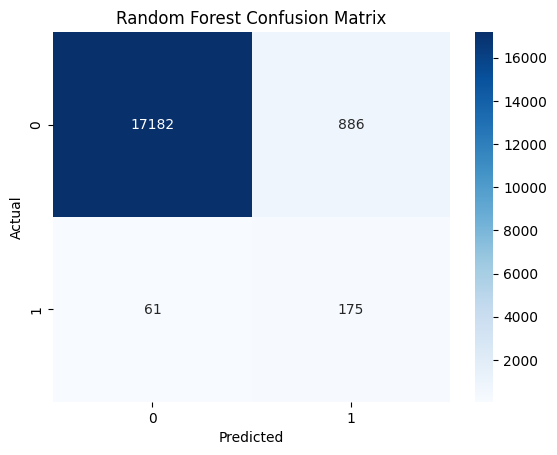

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

Support Vector Machine(SVM)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib

scaler = StandardScaler()

X_train_bal_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test_bal)

pca = PCA(n_components=4)

X_train_pca = pca.fit_transform(X_train_bal_scaled)
X_test_pca = pca.transform(X_test_scaled)

joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")

['pca.pkl']

SVM Accuracy: 0.9178321678321678

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.92      0.96     18068
           1       0.14      1.00      0.24       236

    accuracy                           0.92     18304
   macro avg       0.57      0.96      0.60     18304
weighted avg       0.99      0.92      0.95     18304



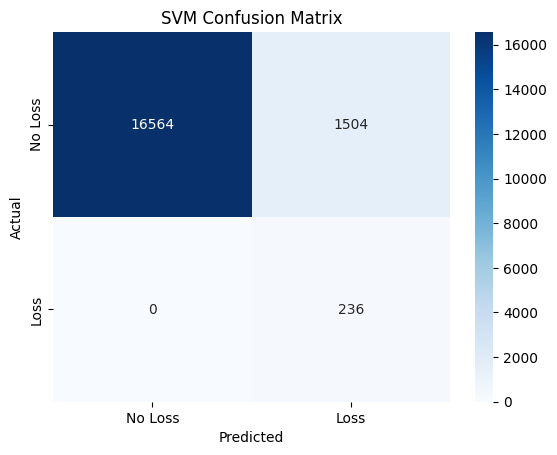

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

svm_model = SVC(kernel='rbf', class_weight='balanced', probability=True)

svm_model.fit(X_train_pca, y_train_bal)

svm_pred = svm_model.predict(X_test_pca)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, svm_pred))

cm = confusion_matrix(y_test, svm_pred)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["No Loss", "Loss"],
            yticklabels=["No Loss", "Loss"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

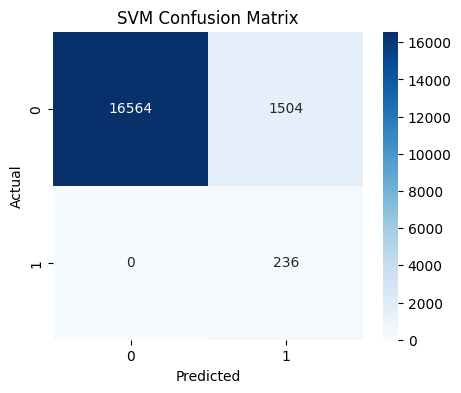

In [ ]:
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

XGBoost

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train_pca, y_train_bal)

xgb_pred = xgb_model.predict(X_test_pca)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.9277207167832168

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.93      0.96     18068
           1       0.15      0.97      0.26       236

    accuracy                           0.93     18304
   macro avg       0.57      0.95      0.61     18304
weighted avg       0.99      0.93      0.95     18304



Neural Networks

In [ ]:
!pip install tensorflow

Epoch 1/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9297 - loss: 0.2028 - val_accuracy: 1.0000 - val_loss: 0.1093
Epoch 2/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9496 - loss: 0.1508 - val_accuracy: 1.0000 - val_loss: 0.1143
Epoch 3/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9496 - loss: 0.1487 - val_accuracy: 1.0000 - val_loss: 0.1091
Epoch 4/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9496 - loss: 0.1481 - val_accuracy: 1.0000 - val_loss: 0.1254
Epoch 5/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9496 - loss: 0.1476 - val_accuracy: 1.0000 - val_loss: 0.1333
Epoch 6/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9497 - loss: 0.1470 - val_accuracy: 1.0000 - val_loss: 0.1422
Epoch 7/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9496 - loss: 0.1470 - val_accuracy: 1.0000 - val_loss: 0.1212
Epoch 8/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9497 - loss: 0.1466 - val_accuracy: 

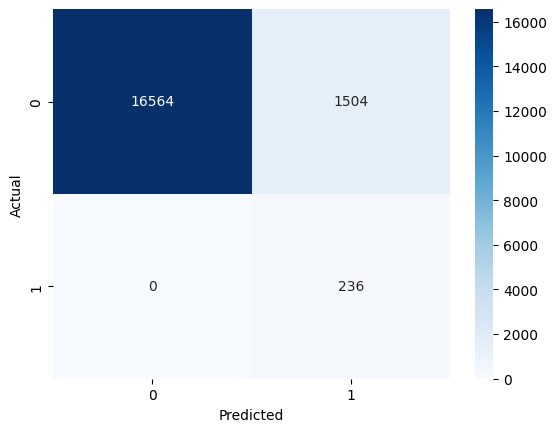

Neural Network model saved successfully.


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model = tf.keras.Sequential([

    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_pca.shape[1],)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(16, activation='relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_pca,
    y_train_bal,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(X_test_pca, y_test)

print("Neural Network Test Accuracy:", test_accuracy)

y_pred_prob = model.predict(X_test_pca)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

model.save("neural_network_model.h5")

print("Neural Network model saved successfully.")

Save and Download Models

In [ ]:
import joblib

joblib.dump(log_model, "logistic_model.pkl")
joblib.dump(rf_model, "random_forest_model.pkl")
joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(xgb_model, "xgboost_model.pkl")

joblib.dump(scaler, "scaler.pkl")

print("All models saved successfully.")

All models saved successfully.


In [ ]:
from google.colab import files

files.download("logistic_model.pkl")
files.download("random_forest_model.pkl")
files.download("svm_model.pkl")
files.download("xgboost_model.pkl")
files.download("neural_network_model.h5")
files.download("scaler.pkl")
files.download("pca.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Test Models for Un-Seen Inputs**

In [ ]:
import joblib
import tensorflow as tf

log_model = joblib.load("logistic_model.pkl")
rf_model = joblib.load("random_forest_model.pkl")
svm_model = joblib.load("svm_model.pkl")
xgb_model = joblib.load("xgboost_model.pkl")

scaler = joblib.load("scaler.pkl")
pca = joblib.load("pca.pkl")

try:
    nn_model = tf.keras.models.load_model(
        "neural_network_model.h5",
        compile=False
    )
    print("✅ Neural Network loaded")
except Exception as e:
    print("⚠️ Neural Network failed to load:", e)
    nn_model = None

print("✅ All models and preprocessing objects loaded successfully.")

✅ Neural Network loaded
✅ All models and preprocessing objects loaded successfully.


In [ ]:
new_packet = [[
    # The selected features, in order, are:
    # ['frame_time_delta', 'iat', 'rolling_std_len', 'rolling_loss_rate']

    0.002,              # frame_time_delta (low delay)
    0.002,              # iat (inter-arrival time)
    0.0,                # rolling_std_len
    0.0                 # rolling_loss_rate
]]

Test SVM

In [ ]:
new_scaled = scaler.transform(new_packet)

new_pca = pca.transform(new_scaled)

svm_prediction = svm_model.predict(new_pca)
log_prediction = log_model.predict(new_pca)

print("SVM:", "Packet Lost" if svm_prediction[0] == 1 else "No Loss")
print("Logistic:", "Packet Lost" if log_prediction[0] == 1 else "No Loss")

SVM: No Loss
Logistic: No Loss


In [ ]:
new_scaled = scaler.transform(new_packet)

new_pca = pca.transform(new_scaled)

rf_prediction = rf_model.predict(new_pca)
xgb_prediction = xgb_model.predict(new_pca)

print("Random Forest:", "Packet Lost" if rf_prediction[0] == 1 else "No Loss")
print("XGBoost:", "Packet Lost" if xgb_prediction[0] == 1 else "No Loss")

Random Forest: No Loss
XGBoost: No Loss


In [ ]:
def predict_packet(packet):
    import numpy as np

    packet = np.array(packet)

    scaled = scaler.transform(packet)

    pca_features = pca.transform(scaled)

    results = {}

    results["Logistic"] = log_model.predict(pca_features)[0]
    results["SVM"] = svm_model.predict(pca_features)[0]
    results["RandomForest"] = rf_model.predict(pca_features)[0]
    results["XGBoost"] = xgb_model.predict(pca_features)[0]

    if nn_model:
        prob = nn_model.predict(pca_features, verbose=0)[0][0]
        results["NeuralNet"] = int(prob > 0.5)
        results["NN_Prob"] = float(prob)
    else:
        results["NeuralNet"] = 0
        results["NN_Prob"] = 0.0

    for model, pred in results.items():
        if model != "NN_Prob":
            print(f"{model}: {'Packet Lost' if pred==1 else 'No Loss'}")

    if "NN_Prob" in results:
        print(f"NN Probability: {results['NN_Prob']:.4f}")

    return results

In [ ]:
new_packet = [[
    80,                 # dst_port
    0.08,               # inter_arrival_time (high delay)
    0.6,                # rolling_loss_rate (HIGH)
    3,                  # duplicate_ack_count (strong signal)
    34813,              # seq
    1,                  # duplicate_ack
    0.02,               # jitter (high)
    29,                 # ack mismatch
    0.25,               # rtt_estimate (high latency)
    1,                  # retransmission
    0.5,                # retransmission_rate
    1,                  # lost_segment
    5000,               # src_port
    1.771739e9
]]

In [ ]:
i = 1

# Features expected by the scaler and models:
# ['frame_time_delta', 'iat', 'rolling_std_len', 'rolling_loss_rate']

for sample in [

    # 🟢 NO LOSS (Stable network) - 4 features
    [0.001, 0.001, 5.0, 0.0],
    [0.0015, 0.0015, 7.0, 0.0],
    [0.0008, 0.0008, 3.0, 0.0],

    # 🟡 BORDERLINE (Mild instability) - 4 features
    [0.01, 0.01, 20.0, 0.1],
    [0.015, 0.015, 25.0, 0.15],

    # 🔴 PACKET LOSS (Strong signals) - 4 features
    # Example: Retransmission with 0 sequence/ack delta, high loss rate
    [0.05, 0.05, 50.0, 0.5],
    [0.06, 0.06, 55.0, 0.6],
    [0.04, 0.04, 45.0, 0.45],

    # 🔴 HEAVY LOSS (Extreme case) - 4 features
    [0.1, 0.1, 100.0, 0.9],
    [0.15, 0.15, 120.0, 0.95],

]:
    print("Sample:", i)
    predict_packet([sample])
    print("-" * 50)
    i += 1

Sample: 1
Logistic: No Loss
SVM: No Loss
RandomForest: No Loss
XGBoost: No Loss
NeuralNet: No Loss
NN Probability: 0.0001
--------------------------------------------------
Sample: 2
Logistic: No Loss
SVM: No Loss
RandomForest: No Loss
XGBoost: No Loss
NeuralNet: No Loss
NN Probability: 0.0001
--------------------------------------------------
Sample: 3
Logistic: No Loss
SVM: No Loss
RandomForest: No Loss
XGBoost: No Loss
NeuralNet: No Loss
NN Probability: 0.0001
--------------------------------------------------
Sample: 4
Logistic: Packet Lost
SVM: Packet Lost
RandomForest: No Loss
XGBoost: No Loss
NeuralNet: Packet Lost
NN Probability: 0.9184
--------------------------------------------------
Sample: 5
Logistic: Packet Lost
SVM: Packet Lost
RandomForest: No Loss
XGBoost: No Loss
NeuralNet: Packet Lost
NN Probability: 0.9451
--------------------------------------------------
Sample: 6
Logistic: Packet Lost
SVM: Packet Lost
RandomForest: Packet Lost
XGBoost: Packet Lost
NeuralNet: Pack

Neural Network

In [ ]:
i = 1

for sample in [
    # Example samples - ensure 4 features in correct order
    # ['frame_time_delta', 'iat', 'rolling_std_len', 'rolling_loss_rate']

    # 🟢 NO LOSS (Stable network) - 4 features
    [0.001, 0.001, 5.0, 0.0],
    [0.0015, 0.0015, 7.0, 0.0],
    [0.0008, 0.0008, 3.0, 0.0],

    # 🟡 BORDERLINE (Mild instability) - 4 features
    [0.01, 0.01, 20.0, 0.1],
    [0.015, 0.015, 25.0, 0.15],

    # 🔴 PACKET LOSS (Strong signals) - 4 features
    [0.05, 0.05, 50.0, 0.5],
    [0.06, 0.06, 55.0, 0.6],
    [0.04, 0.04, 45.0, 0.45],

    # 🔴 HEAVY LOSS (Extreme case) - 4 features
    [0.1, 0.1, 100.0, 0.9],
    [0.15, 0.15, 120.0, 0.95],
]:

    sample_array = np.array([sample])

    sample_scaled = scaler.transform(sample_array)
    sample_pca = pca.transform(sample_scaled) # Apply PCA transformation

    prob = nn_model.predict(sample_pca, verbose=0)

    prediction = (prob > 0.5).astype(int)

    print(f"Sample {i}:")
    print("Input:", sample)
    print("Prediction:", "Packet Lost" if prediction[0][0] == 1 else "No Loss")
    print("Probability of Loss:", float(prob[0][0]))
    print("-" * 40)

    i += 1

Sample 1:
Input: [0.001, 0.001, 5.0, 0.0]
Prediction: No Loss
Probability of Loss: 5.465392314363271e-05
----------------------------------------
Sample 2:
Input: [0.0015, 0.0015, 7.0, 0.0]
Prediction: No Loss
Probability of Loss: 5.466621587402187e-05
----------------------------------------
Sample 3:
Input: [0.0008, 0.0008, 3.0, 0.0]
Prediction: No Loss
Probability of Loss: 5.467158916871995e-05
----------------------------------------
Sample 4:
Input: [0.01, 0.01, 20.0, 0.1]
Prediction: Packet Lost
Probability of Loss: 0.9184496402740479
----------------------------------------
Sample 5:
Input: [0.015, 0.015, 25.0, 0.15]
Prediction: Packet Lost
Probability of Loss: 0.945123016834259
----------------------------------------
Sample 6:
Input: [0.05, 0.05, 50.0, 0.5]
Prediction: Packet Lost
Probability of Loss: 0.98562091588974
----------------------------------------
Sample 7:
Input: [0.06, 0.06, 55.0, 0.6]
Prediction: Packet Lost
Probability of Loss: 0.9903138875961304
---------------

In [ ]:
i = 1

# Features expected by the scaler and models (19 features):
# ['flag_syn', 'tcp_window_size', 'tcp_len', 'tcp_seq', 'ip_len',
#  'frame_time_delta', 'tcp_srcport', 'rolling_std_len', 'rolling_loss_rate',
#  'flag_push', 'tcp_dstport', 'tcp_ack', 'flag_rst', 'flag_fin',
#  'seq_delta', 'iat', 'rolling_mean_len', 'flag_ack', 'ack_delta']

for sample, actual_label in [
    # 🟢 NO LOSS (Stable network) - 4 features
    ([0.001, 0.001, 5.0, 0.0], 0),
    ([0.0015, 0.0015, 7.0, 0.0], 0),
    ([0.0008, 0.0008, 3.0, 0.0], 0),

    # 🟡 BORDERLINE (Mild instability) - 4 features
    ([0.01, 0.01, 20.0, 0.1], 1),
    ([0.015, 0.015, 25.0, 0.15], 1),

    # 🔴 PACKET LOSS (Strong signals) - 4 features
    ([0.05, 0.05, 50.0, 0.5], 1),
    ([0.06, 0.06, 55.0, 0.6], 1),
    ([0.04, 0.04, 45.0, 0.45], 1),

    # 🔴 HEAVY LOSS (Extreme case) - 4 features
    ([0.1, 0.1, 100.0, 0.9], 1),
    ([0.15, 0.15, 120.0, 0.95], 1),
]:

    sample_array = np.array([sample])
    sample_scaled = scaler.transform(sample_array)
    sample_pca = pca.transform(sample_scaled) # Apply PCA transformation

    prob = nn_model.predict(sample_pca, verbose=0)
    prediction = (prob > 0.5).astype(int)

    print(f"Sample {i}:")
    print("Input:", sample)
    print("Actual:", "Packet Lost" if actual_label == 1 else "No Loss")
    print("Predicted:", "Packet Lost" if prediction[0][0] == 1 else "No Loss")
    print("Probability of Loss:", float(prob[0][0]))
    print("-" * 50)

    i += 1

Sample 1:
Input: [0.001, 0.001, 5.0, 0.0]
Actual: No Loss
Predicted: No Loss
Probability of Loss: 5.465392314363271e-05
--------------------------------------------------
Sample 2:
Input: [0.0015, 0.0015, 7.0, 0.0]
Actual: No Loss
Predicted: No Loss
Probability of Loss: 5.466621587402187e-05
--------------------------------------------------
Sample 3:
Input: [0.0008, 0.0008, 3.0, 0.0]
Actual: No Loss
Predicted: No Loss
Probability of Loss: 5.467158916871995e-05
--------------------------------------------------
Sample 4:
Input: [0.01, 0.01, 20.0, 0.1]
Actual: Packet Lost
Predicted: Packet Lost
Probability of Loss: 0.9184496402740479
--------------------------------------------------
Sample 5:
Input: [0.015, 0.015, 25.0, 0.15]
Actual: Packet Lost
Predicted: Packet Lost
Probability of Loss: 0.945123016834259
--------------------------------------------------
Sample 6:
Input: [0.05, 0.05, 50.0, 0.5]
Actual: Packet Lost
Predicted: Packet Lost
Probability of Loss: 0.98562091588974
---------